### **Tabular Q-Learning for the Traveling Salesman Problem**

A minimal, from-scratch implementation that mirrors the Wang et al. (2023) approach but exposes the environment through a clean **Gymnasium-style API**.

**What we build:**
1. `TSPEnv` — a Gymnasium environment for TSP with action masking.
2. A tabular **Q-learning** agent with ε-greedy exploration.
3. Training loop, learning curve, and tour visualization.
4. Sanity check against the brute-force optimum.

**Why tabular?**
- No neural networks, no PyTorch/TF — just NumPy.
- Easy to inspect, debug, and reason about.
- Works for small N (≤ ~10 cities); breaks down beyond that due to the |S|·|A| explosion.
- The Q-table has roughly **N · 2^N** entries, so N=10 → ~10,000 states.

**Don't go fover N=14 it is already 6.2Billions in brute force**


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import permutations
import gymnasium as gym
from gymnasium import spaces

rng = np.random.default_rng(42)

#### **Some Hyperparameters**

In [2]:
NUM_COORDINATES = 14    # number of points for the TSP problem   -- 12 /14 is the maximum otherwose your computer will melt
N_EPISODES = 100_000    # Max number of episodes to run

#### **Transforming the Problem into an MDP layout**

| MDP element     | TSP instantiation |
|-----------------|-------------------|
| **State** $s$       | `(current_city, frozenset of visited cities)` |
| **Action** $a$      | Pick the next (unvisited) city, $a \in \{0, \dots, N-1\}$ |
| **Transition** $P$  | Deterministic — append city, update current and visited |
| **Reward** $R$      | $-d_{ij}$ at each step + $-d_{\text{last},\text{start}}$ on closing |
| **Terminal**    | All cities visited (and we close the tour) |

**Key design point:** the state has to include the visited set, not just the current city. Otherwise the problem isn't Markov — the policy wouldn't know which cities are still legal.

The Q-table is therefore a dict keyed by `(current_city, frozenset_of_visited)` → array of N Q-values.


In [3]:
class TSPEnv(gym.Env):
    """A Gymnasium environment for the symmetric TSP.

    Observation is a dict; the discrete state key used by the tabular
    agent is built by `get_state_key()` and combines `current` and `visited`.
    """

    metadata = {"render_modes": []}

    def __init__(self, coords: np.ndarray, start_city: int = 0):
        super().__init__()
        self.coords = np.asarray(coords, dtype=np.float64)
        self.n = len(coords)
        self.start_city = start_city

        # Pre-compute the distance matrix once.
        diff = self.coords[:, None, :] - self.coords[None, :, :]
        self.dist = np.sqrt((diff ** 2).sum(axis=-1))

        # Spaces.
        self.action_space = spaces.Discrete(self.n)
        self.observation_space = spaces.Dict({
            "current": spaces.Discrete(self.n),
            "visited": spaces.MultiBinary(self.n),
        })

        self.current = None
        self.visited = None
        self.tour = None

    # --- API -------------------------------------------------

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        self.current = self.start_city
        self.visited = np.zeros(self.n, dtype=bool)
        self.visited[self.start_city] = True
        self.tour = [self.start_city]
        return self._obs(), self._info()

    def step(self, action: int):
        if self.visited[action]:
            raise ValueError(f"City {action} already visited (illegal action).")

        reward = -float(self.dist[self.current, action])
        self.current = int(action)
        self.visited[self.current] = True
        self.tour.append(self.current)

        terminated = bool(self.visited.all())
        if terminated:
            # Close the tour: pay the cost of returning to the start city.
            reward += -float(self.dist[self.current, self.start_city])
            self.tour.append(self.start_city)

        return self._obs(), reward, terminated, False, self._info()

    # --- Helpers ---------------------------------------------

    def _obs(self):
        return {"current": self.current, "visited": self.visited.copy()}

    def _info(self):
        # The action mask: True = legal (unvisited) action.
        mask = ~self.visited
        return {"action_mask": mask, "tour": list(self.tour)}

    def get_state_key(self):
        """Hashable state key for the tabular Q-table."""
        return (self.current, frozenset(np.where(self.visited)[0].tolist()))

    def tour_length(self, tour=None):
        tour = tour if tour is not None else self.tour
        return sum(self.dist[tour[i], tour[i + 1]] for i in range(len(tour) - 1))


#### **Build a small TSP instance**

For tabular Q-learning we keep `N` small (here `N = 8`) so we can also brute-force the true optimum for comparison.<br>
Brute force is heavy in resources, don't try large numbers, you can compare the computing cost between them


In [4]:
%%time

N = NUM_COORDINATES
coords = rng.uniform(0, 1, size=(N, 2))

env = TSPEnv(coords, start_city=0)

# Brute-force optimum (only feasible for very small N!)
def brute_force_optimum(env: TSPEnv):
    cities = list(range(env.n))
    start = env.start_city
    others = [c for c in cities if c != start]
    best_len, best_tour = float("inf"), None
    for perm in permutations(others):
        tour = [start, *perm, start]
        L = env.tour_length(tour)
        if L < best_len:
            best_len, best_tour = L, tour
    return best_len, best_tour

opt_len, opt_tour = brute_force_optimum(env)
print(f"Cities: {N}")
print(f"Optimal tour length:  {opt_len:.4f}")
print(f"Optimal tour:         {opt_tour}")

Cities: 14
Optimal tour length:  3.1235
Optimal tour:         [0, 10, 12, 8, 13, 7, 4, 2, 5, 6, 3, 11, 1, 9, 0]
CPU times: user 2h 35min 58s, sys: 662 ms, total: 2h 35min 59s
Wall time: 2h 35min 59s


#### **Q-Learning Agent**
Standard tabular update 

$$Q(s,a) \leftarrow Q(s,a) + \alpha \left[ r + \gamma \max_{a'} Q(s', a') - Q(s,a) \right]$$

Two practical adaptations for TSP:
- **Sparse Q-table.** Most `(state, visited-set)` combinations are never seen. We use a `dict` keyed by the state tuple and lazily allocate an N-length vector of zeros on first visit.
- **Action masking inside the argmax.** The greedy and the bootstrap target both restrict to legal (unvisited) actions. Otherwise the agent could "want" to revisit a city, which would corrupt the Q-values.


In [5]:
class QLearningAgent:
    def __init__(self, n_actions: int, alpha: float = 0.1,
                 gamma: float = 0.95, eps_start: float = 1.0,
                 eps_end: float = 0.01):
        self.n_actions = n_actions
        self.alpha = alpha
        self.gamma = gamma
        self.eps_start = eps_start
        self.eps_end = eps_end
        self.Q = {}  # state_key -> np.ndarray of length n_actions

    def _get_q(self, state_key):
        if state_key not in self.Q:
            self.Q[state_key] = np.zeros(self.n_actions, dtype=np.float64)
        return self.Q[state_key]

    def select_action(self, state_key, action_mask, eps, rng):
        legal = np.where(action_mask)[0]
        if rng.random() < eps:
            return int(rng.choice(legal))
        q = self._get_q(state_key).copy()
        q[~action_mask] = -np.inf  # mask illegal actions
        return int(np.argmax(q))

    def update(self, s, a, r, s_next, next_mask, done):
        q_sa = self._get_q(s)[a]
        if done:
            target = r
        else:
            q_next = self._get_q(s_next).copy()
            q_next[~next_mask] = -np.inf
            target = r + self.gamma * q_next.max()
        self._get_q(s)[a] += self.alpha * (target - q_sa)

    def schedule_eps(self, episode, total_episodes):
        # Linear decay from eps_start to eps_end.
        frac = min(1.0, episode / total_episodes)
        return self.eps_start + frac * (self.eps_end - self.eps_start)


#### **Training loop**

In [13]:
%%time

def train(env: TSPEnv, agent: QLearningAgent, n_episodes: int,
          seed: int = 0, log_every: int = 500):
    train_rng = np.random.default_rng(seed)
    tour_lengths = []
    best_len = float("inf")
    best_tour = None

    for ep in range(n_episodes):
        obs, info = env.reset()
        s = env.get_state_key()
        mask = info["action_mask"]
        eps = agent.schedule_eps(ep, n_episodes)
        done = False
        episode_return = 0.0

        while not done:
            a = agent.select_action(s, mask, eps, train_rng)
            obs, r, terminated, truncated, info = env.step(a)
            s_next = env.get_state_key()
            next_mask = info["action_mask"]
            done = terminated or truncated
            agent.update(s, a, r, s_next, next_mask, done)
            s, mask = s_next, next_mask
            episode_return += r

        tour_len = env.tour_length()
        tour_lengths.append(tour_len)
        if tour_len < best_len:
            best_len, best_tour = tour_len, list(env.tour)

        if (ep + 1) % log_every == 0:
            recent = np.mean(tour_lengths[-log_every:])
            print(f"Ep {ep+1:5d} | eps={eps:.3f} | "
                  f"recent avg len={recent:.4f} | best so far={best_len:.4f}")

    return tour_lengths, best_len, best_tour


agent = QLearningAgent(
    n_actions=N,
    alpha=0.1,
    gamma=0.95,
    eps_start=1.0,
    eps_end=0.01,
)

tour_lengths, best_len, best_tour = train(env, agent, N_EPISODES, seed=0)
print(f"\nBest tour found: length = {best_len:.4f}")
print(f"Optimal:         length = {opt_len:.4f}")
print(f"Gap:             {(best_len - opt_len) / opt_len * 100:.2f}%")


Ep   500 | eps=0.995 | recent avg len=7.5939 | best so far=5.4560
Ep  1000 | eps=0.990 | recent avg len=7.6004 | best so far=5.0160
Ep  1500 | eps=0.985 | recent avg len=7.6321 | best so far=5.0160
Ep  2000 | eps=0.980 | recent avg len=7.5807 | best so far=5.0160
Ep  2500 | eps=0.975 | recent avg len=7.6131 | best so far=5.0160
Ep  3000 | eps=0.970 | recent avg len=7.5976 | best so far=4.9698
Ep  3500 | eps=0.965 | recent avg len=7.5385 | best so far=4.9698
Ep  4000 | eps=0.960 | recent avg len=7.5863 | best so far=4.9698
Ep  4500 | eps=0.955 | recent avg len=7.5651 | best so far=4.9698
Ep  5000 | eps=0.951 | recent avg len=7.5181 | best so far=4.6926
Ep  5500 | eps=0.946 | recent avg len=7.5866 | best so far=4.6926
Ep  6000 | eps=0.941 | recent avg len=7.5656 | best so far=4.6926
Ep  6500 | eps=0.936 | recent avg len=7.5511 | best so far=4.6926
Ep  7000 | eps=0.931 | recent avg len=7.4570 | best so far=4.6926
Ep  7500 | eps=0.926 | recent avg len=7.4833 | best so far=4.6926
Ep  8000 |

#### **Learning Curve**

We verify learning process of the agent

We plot the moving average of episode tour length against episodes and overlay the brute-force optimum.


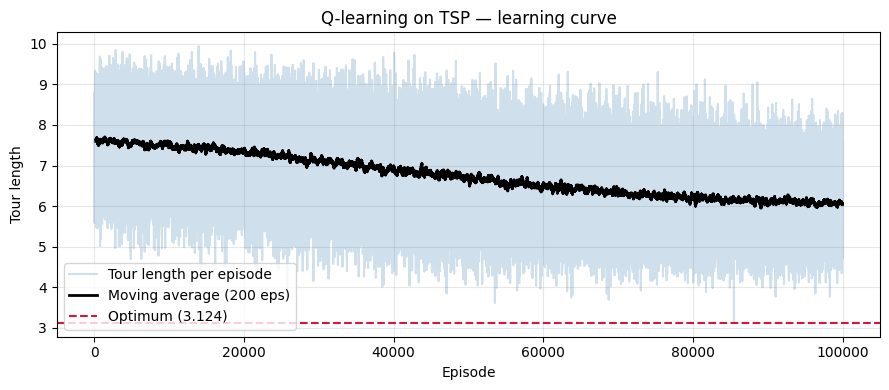

In [7]:
window = 200
lengths = np.array(tour_lengths)
moving_avg = np.convolve(lengths, np.ones(window)/window, mode="valid")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(lengths, alpha=0.25, label="Tour length per episode", color="steelblue")
ax.plot(np.arange(window-1, len(lengths)), moving_avg,
        label=f"Moving average ({window} eps)", color="black", linewidth=2)
ax.axhline(opt_len, color="crimson", linestyle="--", label=f"Optimum ({opt_len:.3f})")
ax.set_xlabel("Episode")
ax.set_ylabel("Tour length")
ax.set_title("Q-learning on TSP — learning curve")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


#### **Visualize Coordinates of random points**
Can we guess the topology of the solution?

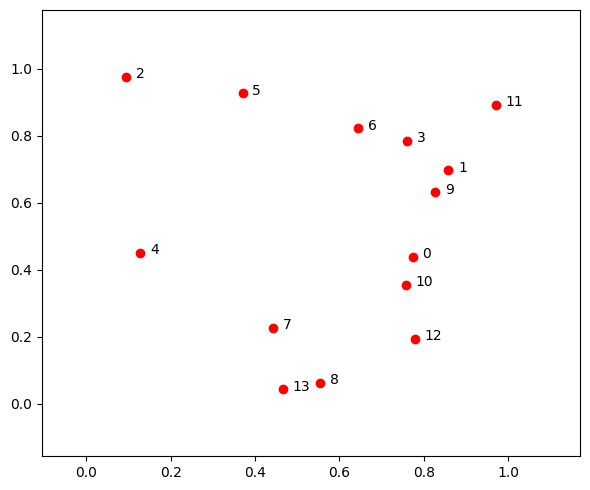

In [8]:
fig, ax = plt.subplots(figsize=(6, 5))

# 1. Plot the actual points so the axes scale correctly
x_vals, y_vals = zip(*coords)
ax.scatter(x_vals, y_vals, color='red', zorder=5) 

# 2. Loop and annotate
for i, (x, y) in enumerate(coords):
    # Format the string to show the index and the actual (x, y) coordinates
    label = f"{i}" 
    
    ax.annotate(
        label, 
        (x, y), 
        textcoords="offset points", 
        xytext=(7, 7),             # Pixels offset from the point
        ha='left',                 # Horizontal alignment
        va='top',               # Vertical alignment
        fontsize=10
    )

# 3. Add some padding to the plot limits so text doesn't get cut off
ax.set_xlim(min(x_vals) - 0.2, max(x_vals) + 0.2)
ax.set_ylim(min(y_vals) - 0.2, max(y_vals) + 0.2)

plt.tight_layout()
plt.show()

#### **Visualize the learned tour vs. the optimum**

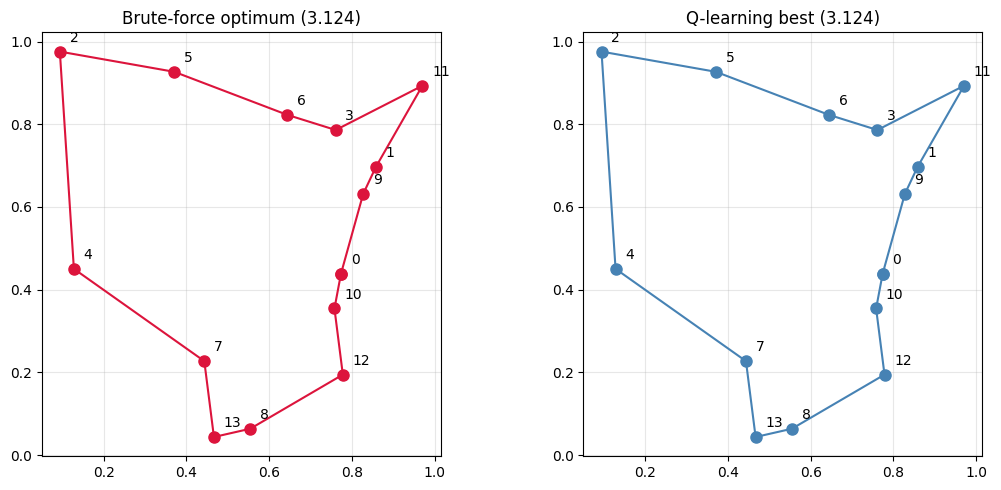

In [9]:
def plot_tour(ax, coords, tour, title, color):
    xs = coords[tour, 0]
    ys = coords[tour, 1]
    ax.plot(xs, ys, "-o", color=color, markersize=8, linewidth=1.5)
    for i, (x, y) in enumerate(coords):
        ax.annotate(str(i), (x, y), textcoords="offset points",
                    xytext=(7, 7), fontsize=10)
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.grid(alpha=0.3)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
plot_tour(axes[0], coords, opt_tour,
          f"Brute-force optimum ({opt_len:.3f})", "crimson")
plot_tour(axes[1], coords, best_tour,
          f"Q-learning best ({best_len:.3f})", "steelblue")
plt.tight_layout()
plt.show()


#### **Greedy rollout from the learned Q-table - The Policy!**

After training, run **one** purely greedy episode (ε = 0) — this is the deterministic policy the agent has actually learned.

> **A note on what you'll see.** The agent typically *discovered* the optimum at some point during exploration (see "best so far" in the training log), but the **greedy rollout often produces a worse tour**. This is a real and well-known limitation of tabular Q-learning on this kind of problem: a few states deep in the tree may be visited only once or twice, so their Q-values haven't converged. A deterministic argmax then makes a poor choice and the rest of the tour suffers. Remedies include training longer, lower learning rate, more aggressive exploration, or — the deep-RL answer — function approximation that generalizes across similar states.


In [10]:
def greedy_rollout(env: TSPEnv, agent: QLearningAgent):
    obs, info = env.reset()
    s = env.get_state_key()
    mask = info["action_mask"]
    done = False
    while not done:
        q = agent._get_q(s).copy()
        q[~mask] = -np.inf
        a = int(np.argmax(q))
        obs, r, terminated, truncated, info = env.step(a)
        s = env.get_state_key()
        mask = info["action_mask"]
        done = terminated or truncated
    return list(env.tour), env.tour_length()

greedy_tour, greedy_len = greedy_rollout(env, agent)
print(f"Greedy rollout tour:   {greedy_tour}")
print(f"Greedy rollout length: {greedy_len:.4f}")
print(f"Optimal length:        {opt_len:.4f}")
print(f"Gap:                   {(greedy_len - opt_len) / opt_len * 100:.2f}%")
print(f"Distinct states visited during training: {len(agent.Q):,}")


Greedy rollout tour:   [0, 10, 13, 4, 6, 9, 5, 7, 1, 11, 3, 12, 8, 2, 0]
Greedy rollout length: 7.0159
Optimal length:        3.1235
Gap:                   124.62%
Distinct states visited during training: 52,996


#### **From the (Wang et al 2023) paper, try 3 different reward functions**

The Wang paper compared three reward functions:

| Name | Formula |
|------|---------|
| $R_1$ | $+1/d_{ij}$ (reciprocal) |
| $R_2$ | $-d_{ij}$ (negative distance — what we used) |
| $R_3$ | $-d_{ij}^2$ (penalize long edges more strongly) |

They reported $R_1$ as the best on most TSPLIB instances. We can subclass our env to try the same.


In [11]:
class TSPEnvReward(TSPEnv):
    """TSPEnv with selectable reward variant from Wang et al."""

    def __init__(self, coords, reward: str = "R2", **kwargs):
        super().__init__(coords, **kwargs)
        assert reward in ("R1", "R2", "R3")
        self.reward_kind = reward

    def _edge_reward(self, i, j):
        d = float(self.dist[i, j])
        if self.reward_kind == "R1":
            return 1.0 / d if d > 0 else 0.0
        if self.reward_kind == "R2":
            return -d
        return -(d ** 2)  # R3

    def step(self, action):
        if self.visited[action]:
            raise ValueError(f"City {action} already visited.")
        reward = self._edge_reward(self.current, action)
        self.current = int(action)
        self.visited[self.current] = True
        self.tour.append(self.current)
        terminated = bool(self.visited.all())
        if terminated:
            reward += self._edge_reward(self.current, self.start_city)
            self.tour.append(self.start_city)  # close the loop
        return self._obs(), reward, terminated, False, self._info()


def run_experiment(reward_kind, n_episodes=5000, seeds=(0, 1, 2)):
    """Run N seeds and return (mean_best, std_best) across seeds."""
    best_lengths = []
    for s in seeds:
        e = TSPEnvReward(coords, reward=reward_kind, start_city=0)
        a = QLearningAgent(n_actions=N, alpha=0.1, gamma=0.95,
                           eps_start=1.0, eps_end=0.01)
        _, bL, _ = train(e, a, n_episodes, seed=s, log_every=99999)
        best_lengths.append(bL)
    return float(np.mean(best_lengths)), float(np.std(best_lengths))

print(f"{'Reward':<6} {'mean best':>10} {'std':>8} {'mean gap':>10}")
for kind in ("R1", "R2", "R3"):
    m, sd = run_experiment(kind)
    gap = (m - opt_len) / opt_len * 100
    print(f"{kind:<6} {m:>10.4f} {sd:>8.4f} {gap:>9.2f}%")

print(f"\nOptimum: {opt_len:.4f}")
print("\nNote: on N=8 all three rewards usually find the optimum during "
      "exploration; differences between R1/R2/R3 become visible on larger "
      "instances, as reported by Wang et al.")


Reward  mean best      std   mean gap
R1         4.1255   0.2867     32.08%
R2         4.0410   0.2533     29.37%
R3         3.4988   0.1546     12.02%

Optimum: 3.1235

Note: on N=8 all three rewards usually find the optimum during exploration; differences between R1/R2/R3 become visible on larger instances, as reported by Wang et al.


#### **Some comments on the problem and solution**

**What works well:**
- The full Gymnasium API: `reset()`, `step()`, observation/action spaces, action mask via `info`.
- Clean separation between environment and agent — swap the agent for SARSA or Double Q-Learning by changing the `update` rule only.
- Tabular Q-learning reaches the brute-force optimum on N=8 in a few seconds.

**Where it breaks:**
- State space grows as $N \cdot 2^N$. At N=15 that's ~500k states, at N=20 it's ~20M. The dict starts thrashing, episodes get slow, and exploration becomes hopeless.
- This is exactly why the **deep RL approach** (Bello 2016, the Attention Model, RL4CO, Jumanji) exists — neural networks generalize across states instead of memorizing each one.

**Natural next steps to try in this notebook:**
1. Implement SARSA: replace `q_next.max()` with `q_next[next_action]` (on-policy).
2. Implement Double Q-Learning: keep two tables $Q^A$, $Q^B$ and alternate which one updates.
3. Compare ε-decay schedules (linear, exponential, step) as in Wang et al.
4. Move to a learned function approximator — once that's needed, the same `TSPEnv` plugs straight into RL4CO or Stable-Baselines3 with `MaskablePPO`.
